# Evaluation — CartPole-v1
### DQN baseline · PPO baseline · DQN+Precedence (C1/C2/C3) · PPO+Precedence (C1/C2/C3)

**What this notebook measures (pre-ablation essentials):**

| Metric | What it tells us |
|---|---|
| **Mean ± std reward** (100 greedy eps) | Final performance — primary paper number |
| **Episodes to solve** (mean-25 ≥ 475) | Sample efficiency |
| **Training stability** (std last 50 eps) | Reliability of learned policy |
| **Robustness** (noise σ = 0.05 / 0.1 / 0.2) | How well the policy generalises under perturbation |
| **Learning curve** | Visual story — all agents on one plot |
| **Summary table** | Paper-ready comparison |

## 1. Imports & Paths

In [61]:
import os, json
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# ── Paths — adjust to your folder structure ──────────────────────────────────
BASE_DIR = ".."   # root of your project

# Baseline checkpoints
DQN_BASELINE_PTH  = os.path.join(BASE_DIR, "DQN_plots/CartPole-v1/dqn_agent.pth")
PPO_BASELINE_PTH  = os.path.join(BASE_DIR, "PPO_plots/CartPole-v1/ppo_agent.pth")

# Precedence checkpoints
DQN_PREC_DIR = os.path.join(BASE_DIR, "world_model/checkpoints_dqn_with_precedence_CartPole")
PPO_PREC_DIR = os.path.join(BASE_DIR, "world_model/checkpoints_ppo_with_precedence")

# Training history JSONs (saved by training notebooks)
DQN_BASELINE_JSON = os.path.join(BASE_DIR, "DQN_plots/CartPole-v1/dqn_metrics.json")
PPO_BASELINE_JSON = os.path.join(BASE_DIR, "PPO_plots/CartPole-v1/ppo_metrics.json")
DQN_PREC_JSON     = os.path.join(DQN_PREC_DIR, "dqn_with_precedence_CartPole_metrics.json")
PPO_PREC_JSON     = os.path.join(PPO_PREC_DIR, "ppo_with_precedence_results.json")

# Evaluation settings
ENV_NAME      = "CartPole-v1"
N_EVAL_EPS    = 100      # greedy episodes for final performance
NOISE_LEVELS  = [0.0, 0.05, 0.1, 0.2]
SOLVE_THRESH  = 475      # CartPole-v1 solve threshold (mean-25)
SEED          = 42
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PLOT_DIR = "eval_plots_CartPole"
os.makedirs(PLOT_DIR, exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"✅ Setup OK  |  device={DEVICE}  |  eval_eps={N_EVAL_EPS}")
print(f"  Noise levels : {NOISE_LEVELS}")
print(f"  Solve thresh : {SOLVE_THRESH}")


✅ Setup OK  |  device=cpu  |  eval_eps=100
  Noise levels : [0.0, 0.05, 0.1, 0.2]
  Solve thresh : 475


## 2. Network Definitions (must match training)

In [62]:
# ── DQN Q-Network ─────────────────────────────────────────────────────────────
class QNetwork(nn.Module):
    def __init__(self, obs_dim=4, n_actions=2, hidden=(64,64)):
        super().__init__()
        layers, prev = [], obs_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, n_actions))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

# ── PPO Actor ─────────────────────────────────────────────────────────────────
class Actor(nn.Module):
    def __init__(self, obs_dim=4, n_actions=2, hidden=(64,64)):
        super().__init__()
        layers, prev = [], obs_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.Tanh()]
            prev = h
        layers.append(nn.Linear(prev, n_actions))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

print("✅ Network classes defined")


✅ Network classes defined


## 3. Load All Agents

In [63]:
def load_dqn(path, obs_dim=4, n_actions=2, hidden=(64,64)):
    """Load a DQN Q-network from checkpoint."""
    net = QNetwork(obs_dim, n_actions, hidden).to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    # Handle both raw state_dict and nested dict
    sd = ckpt.get("q_net", ckpt) if isinstance(ckpt, dict) else ckpt
    net.load_state_dict(sd)
    net.eval()

    return net


# ── Charger mean/std depuis le checkpoint ─────────────────────────
def load_dqn_with_norm(path, obs_dim=4, n_actions=2, hidden=(64,64)):
    """Load a DQN Q-network from checkpoint."""
    net  = QNetwork(obs_dim, n_actions, hidden).to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    # Handle both raw state_dict and nested dict
    sd   = ckpt.get("q_net", ckpt) if isinstance(ckpt, dict) else ckpt
    net.load_state_dict(sd)
    net.eval()
    
    # Récupérer la normalisation sauvegardée
    state_mean = ckpt.get("state_mean", None)
    state_std  = ckpt.get("state_std",  None)
    return net, state_mean, state_std

def load_ppo_with_norm(path, obs_dim=4, n_actions=2, hidden=(64,64)):
    """Load PPO Actor + normalisation stats from checkpoint."""
    net  = Actor(obs_dim, n_actions, hidden).to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    sd   = ckpt.get("actor", ckpt) if isinstance(ckpt, dict) else ckpt
    net.load_state_dict(sd)
    net.eval()
    state_mean = ckpt.get("state_mean", None)
    state_std  = ckpt.get("state_std",  None)
    return net, state_mean, state_std



def load_ppo(path, obs_dim=4, n_actions=2, hidden=(64,64)):
    """Load a PPO Actor from checkpoint."""
    net = Actor(obs_dim, n_actions, hidden).to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    sd = ckpt.get("actor", ckpt) if isinstance(ckpt, dict) else ckpt
    net.load_state_dict(sd)
    net.eval()
    return net

# ── Load baselines ─────────────────────────────────────────────────────────────
agents = {}   # name → (net, type)  type ∈ {'dqn', 'ppo'}

if os.path.exists(DQN_BASELINE_PTH):
    agents["DQN baseline"] = (load_dqn(DQN_BASELINE_PTH), "dqn")
    print(f"✅ DQN baseline loaded")
else:
    print(f"⚠️  DQN baseline not found: {DQN_BASELINE_PTH}")

if os.path.exists(PPO_BASELINE_PTH):
    agents["PPO baseline"] = (load_ppo(PPO_BASELINE_PTH), "ppo")
    print(f"✅ PPO baseline loaded")
else:
    print(f"⚠️  PPO baseline not found: {PPO_BASELINE_PTH}")

# ── Dictionnaire étendu : (net, type, mean, std) ──────────────────
for cfg in [1, 2, 3]:
    path = os.path.join(DQN_PREC_DIR, f"dqn_prec_cartpole_config{cfg}.pt")
    if os.path.exists(path):
        net, s_mean, s_std = load_dqn_with_norm(path, hidden=(128,128))
        agents[f"DQN+Prec C{cfg}"] = (net, "dqn", s_mean, s_std)
        print(f"✅ C{cfg} — mean={s_mean}, std={s_std}")
    else:
        print(f"⚠️  Not found: {path}")



# # ── Load DQN + Precedence ──────────────────────────────────────────────────────
# for cfg in [1, 2, 3]:
#     path = os.path.join(DQN_PREC_DIR, f"dqn_prec_cartpole_config{cfg}.pt")
#     if os.path.exists(path):
#         agents[f"DQN+Prec C{cfg}"] = (load_dqn(path,hidden=(128,128)), "dqn")
#         print(f"✅ DQN+Prec Config {cfg} loaded")
#     else:
#         print(f"⚠️  Not found: {path}")

# ── Load PPO + Precedence ──────────────────────────────────────────────────────
for cfg in [1, 2, 3]:
    path = os.path.join(PPO_PREC_DIR, f"ppo_config{cfg}.pth")
    if os.path.exists(path):
        net, s_mean, s_std = load_ppo_with_norm(path)
        agents[f"PPO+Prec C{cfg}"] = (net, "ppo", s_mean, s_std)
        print(f"✅ PPO+Prec C{cfg} — mean={s_mean}, std={s_std}")
    else:
        print(f"⚠️  Not found: {path}")


# for cfg in [1, 2, 3]:
#     path = os.path.join(PPO_PREC_DIR, f"ppo_config{cfg}.pth")
#     if os.path.exists(path):
#         agents[f"PPO+Prec C{cfg}"] = (load_ppo(path), "ppo")
#         print(f"✅ PPO+Prec Config {cfg} loaded")
#     else:
#         print(f"⚠️  Not found: {path}")

print(f"\n📦 {len(agents)} agents loaded: {list(agents.keys())}")


# 1. Vérifier ce qui est dans le checkpoint
path = os.path.join(DQN_PREC_DIR, f"dqn_prec_cartpole_config1.pt")
ckpt = torch.load(path, map_location="cpu", weights_only=False)
print(type(ckpt))
print(ckpt.keys() if isinstance(ckpt, dict) else "state_dict direct")

# 2. Vérifier l'architecture réelle des poids
for k, v in (ckpt.get("q_net", ckpt) if isinstance(ckpt, dict) else ckpt).items():
    print(k, v.shape)

✅ DQN baseline loaded
✅ PPO baseline loaded
✅ C1 — mean=[-0.00020712 -0.02029223  0.00405843  0.02626351], std=[0.48820907 0.80932426 0.12245946 0.66561514]
✅ C2 — mean=[-0.00020712 -0.02029223  0.00405843  0.02626351], std=[0.48820907 0.80932426 0.12245946 0.66561514]
✅ C3 — mean=[-0.00020712 -0.02029223  0.00405843  0.02626351], std=[0.48820907 0.80932426 0.12245946 0.66561514]
✅ PPO+Prec C1 — mean=[-0.00020712 -0.02029223  0.00405843  0.02626351], std=[0.48820907 0.80932426 0.12245946 0.66561514]
✅ PPO+Prec C2 — mean=[-0.00020712 -0.02029223  0.00405843  0.02626351], std=[0.48820907 0.80932426 0.12245946 0.66561514]
✅ PPO+Prec C3 — mean=[-0.00020712 -0.02029223  0.00405843  0.02626351], std=[0.48820907 0.80932426 0.12245946 0.66561514]

📦 8 agents loaded: ['DQN baseline', 'PPO baseline', 'DQN+Prec C1', 'DQN+Prec C2', 'DQN+Prec C3', 'PPO+Prec C1', 'PPO+Prec C2', 'PPO+Prec C3']
<class 'dict'>
dict_keys(['q_net', 'target_net', 'env_name', 'state_dim', 'action_dim', 'hidden', 'world_mod

## 4. Evaluation Functions

Two functions that work for both DQN and PPO:
- `run_greedy_episodes` — pure greedy, no noise
- `run_noisy_episodes`  — Gaussian noise injected into observations at each step

In [64]:
@torch.no_grad()
def select_action(net, obs_np: np.ndarray, agent_type: str) -> int:
    """
    Greedy action selection.
    DQN : argmax Q(s, ·)
    PPO : argmax logits (deterministic — no sampling at eval time)
    """
    obs_t = torch.FloatTensor(obs_np).unsqueeze(0).to(DEVICE)
    out   = net(obs_t)
    return int(out.argmax(dim=-1).item())


def run_greedy_episodes_norm(net, agent_type, n_eps=N_EVAL_EPS,
                             noise_std=0.0, seed_offset=0,
                             state_mean=None, state_std=None):
    env     = gym.make(ENV_NAME)
    rewards = []
    for ep in range(n_eps):
        obs, _ = env.reset(seed=SEED + seed_offset + ep)
        ep_r, done = 0.0, False
        while not done:
            if noise_std > 0:
                obs = obs + np.random.randn(*obs.shape).astype(np.float32) * noise_std
            # ← Normaliser si mean/std disponibles
            obs_input = obs
            if state_mean is not None and state_std is not None:
                obs_input = (obs - state_mean) / (state_std + 1e-8)
            action = select_action(net, obs_input, agent_type)
            obs, r, term, trunc, _ = env.step(action)
            done  = term or trunc
            ep_r += r
        rewards.append(ep_r)
    env.close()
    return rewards


def run_greedy_episodes(net, agent_type: str,
                        n_eps: int = N_EVAL_EPS,
                        noise_std: float = 0.0,
                        seed_offset: int = 0) -> list:
    """
    Run n_eps episodes with optional Gaussian observation noise.
    Returns list of episode returns.
    """
    env     = gym.make(ENV_NAME)
    rewards = []

    for ep in range(n_eps):
        obs, _ = env.reset(seed=SEED + seed_offset + ep)
        ep_r, done = 0.0, False
        while not done:
            if noise_std > 0:
                obs = obs + np.random.randn(*obs.shape).astype(np.float32) * noise_std
            action = select_action(net, obs, agent_type)
            obs, r, term, trunc, _ = env.step(action)
            done  = term or trunc
            ep_r += r
        rewards.append(ep_r)

    env.close()
    return rewards


print("✅ Evaluation functions defined")


✅ Evaluation functions defined


In [65]:
def evaluate_agent(name, agent_tuple, n_eps, noise_std=0.0, seed_offset=0):
    """
    Dispatch automatiquement vers:
    - DQN normal → run_greedy_episodes
    - DQN+Prec avec norm → run_greedy_episodes_norm
    - PPO → run_greedy_episodes
    """
    # cas 1: DQN baseline ou PPO baseline
    if len(agent_tuple) == 2:
        net, atype = agent_tuple

        return run_greedy_episodes(
            net,
            atype,
            n_eps=n_eps,
            noise_std=noise_std,
            seed_offset=seed_offset
        )

    # cas 2: DQN+Precedence avec normalisation
    elif len(agent_tuple) == 4:
        net, atype, state_mean, state_std = agent_tuple

        return run_greedy_episodes_norm(
            net,
            atype,
            n_eps=n_eps,
            noise_std=noise_std,
            seed_offset=seed_offset,
            state_mean=state_mean,
            state_std=state_std
        )

    else:
        raise ValueError(f"Unknown agent format for {name}: {agent_tuple}")

## 5. Metric: Final Performance (100 greedy episodes)

In [66]:
print(f"\n{'='*65}")
print(f"  FINAL PERFORMANCE — {N_EVAL_EPS} greedy episodes (no noise)")
print(f"{'='*65}\n")

perf_results = {}   # name → {'mean', 'std', 'min', 'max', 'rewards'}

for name, agent_tuple in agents.items():
    rewards = evaluate_agent(
        name,
        agent_tuple,
        n_eps=N_EVAL_EPS,
        noise_std=0.0,
        seed_offset=1000
    )
    perf_results[name] = {
        'mean'    : float(np.mean(rewards)),
        'std'     : float(np.std(rewards)),
        'min'     : float(np.min(rewards)),
        'max'     : float(np.max(rewards)),
        'rewards' : rewards,
    }
    print(f"  {name:<20}  mean={np.mean(rewards):6.1f}  "
          f"std={np.std(rewards):5.1f}  "
          f"min={np.min(rewards):5.0f}  max={np.max(rewards):5.0f}")



  FINAL PERFORMANCE — 100 greedy episodes (no noise)

  DQN baseline          mean= 143.2  std=  5.0  min=  132  max=  154
  PPO baseline          mean= 500.0  std=  0.0  min=  500  max=  500
  DQN+Prec C1           mean= 455.6  std= 70.9  min=  227  max=  500
  DQN+Prec C2           mean=  89.7  std=  2.1  min=   86  max=   95
  DQN+Prec C3           mean=  89.8  std=  2.2  min=   85  max=   94
  PPO+Prec C1           mean= 500.0  std=  0.0  min=  500  max=  500
  PPO+Prec C2           mean= 500.0  std=  0.0  min=  500  max=  500
  PPO+Prec C3           mean= 500.0  std=  0.0  min=  500  max=  500


## 6. Metric: Sample Efficiency (episodes to solve)

In [20]:
def episodes_to_solve(rewards_history: list,
                      threshold: float = SOLVE_THRESH,
                      window: int = 25) -> int:
    """
    Returns the first episode index where mean-{window} >= threshold.
    Returns -1 if never solved.
    """
    rw = np.array(rewards_history)
    for i in range(window - 1, len(rw)):
        if np.mean(rw[i - window + 1 : i + 1]) >= threshold:
            return i + 1   # 1-indexed episode number
    return -1   # never solved within training


def load_reward_history(json_path: str, key: str = None) -> list:
    """
    Load episode reward history from a saved JSON.
    Handles multiple formats:
    - Baseline format (new): {"all_episode_rewards": [...]}
    - Baseline format (old): {"train": {"episode_rewards": [...]}}
    - Precedence format: {"config_1": {"rewards": [...]}}
    - Flat list: [reward1, reward2, ...]
    """
    if not os.path.exists(json_path):
        return []
    with open(json_path) as f:
        data = json.load(f)
    
    # Precedence format with specific config key
    if key:
        return data.get(key, {}).get("rewards", [])
    
    # Flat list (simple format)
    if isinstance(data, list):
        return data
    
    # New baseline format: top-level "all_episode_rewards"
    if "all_episode_rewards" in data:
        return data.get("all_episode_rewards", [])
    
    # Old baseline format: check for "train" -> "episode_rewards"
    if "train" in data:
        train_data = data["train"]
        # Try various possible keys for episode rewards
        for key_name in ["episode_rewards", "rewards", "train_rewards"]:
            if key_name in train_data:
                return train_data[key_name]
    
    # Fallback: check for top-level "rewards" key
    if "rewards" in data:
        return data.get("rewards", [])
    
    return []


print(f"\n{'='*65}")
print(f"  SAMPLE EFFICIENCY — episodes to first mean-25 ≥ {SOLVE_THRESH}")
print(f"{'='*65}\n")

# Load training histories
histories = {}

# Baselines — load from JSON if available, else mark as unknown
for label, json_path, key in [
    ("DQN baseline",  DQN_BASELINE_JSON, None),
    ("PPO baseline",  PPO_BASELINE_JSON, None),
]:
    h = load_reward_history(json_path, key)
    if h:
        histories[label] = h
    else:
        if os.path.exists(json_path):
            print(f"  ⚠️  {label}: episode history not stored in JSON "
                  f"(only summary stats available)")
        else:
            print(f"  ⚠️  {label}: JSON file not found at {json_path}")

# Precedence — load from consolidated JSON
for json_path, prefix in [(DQN_PREC_JSON, "DQN+Prec"), (PPO_PREC_JSON, "PPO+Prec")]:
    if os.path.exists(json_path):
        with open(json_path) as f:
            data = json.load(f)
        for cfg_key, cfg_data in data.items():
            cfg_num = cfg_key.split("_")[-1]   # "config_1" → "1"
            label   = f"{prefix} C{cfg_num}"
            histories[label] = cfg_data.get("rewards", [])

solve_results = {}
for name, h in histories.items():
    ep = episodes_to_solve(h)
    solve_results[name] = ep
    solved_str = f"ep {ep:4d}" if ep > 0 else "never  "
    print(f"  {name:<20}  solved at: {solved_str}  "
          f"(history length: {len(h)} eps)")


  SAMPLE EFFICIENCY — episodes to first mean-25 ≥ 475

  DQN baseline          solved at: ep  341  (history length: 600 eps)
  PPO baseline          solved at: ep  798  (history length: 871 eps)
  DQN+Prec C1           solved at: never    (history length: 500 eps)
  DQN+Prec C2           solved at: never    (history length: 500 eps)
  DQN+Prec C3           solved at: never    (history length: 500 eps)
  PPO+Prec C1           solved at: ep  654  (history length: 757 eps)
  PPO+Prec C2           solved at: ep  373  (history length: 439 eps)
  PPO+Prec C3           solved at: ep  582  (history length: 712 eps)


## 7. Metric: Training Stability (std of last 50 episodes)

In [68]:
print(f"\n{'='*65}")
print(f"  TRAINING STABILITY — std of reward over last 50 training eps")
print(f"{'='*65}\n")

stability_results = {}
for name, h in histories.items():
    if len(h) >= 50:
        s = float(np.std(h[-50:]))
        m = float(np.mean(h[-50:]))
        stability_results[name] = {'mean': m, 'std': s}
        print(f"  {name:<20}  mean={m:6.1f}  std={s:5.1f}")
    else:
        print(f"  {name:<20}  insufficient history ({len(h)} eps)")



  TRAINING STABILITY — std of reward over last 50 training eps

  DQN+Prec C1           mean= 147.3  std= 91.5
  DQN+Prec C2           mean= 111.2  std= 80.5
  DQN+Prec C3           mean= 116.7  std= 90.5
  PPO+Prec C1           mean= 417.3  std=120.1
  PPO+Prec C2           mean= 480.0  std= 66.9
  PPO+Prec C3           mean= 490.0  std= 50.8


## 8. Metric: Robustness under Observation Noise

Evaluates each agent under increasing Gaussian noise on observations.
CartPole obs = [x, x_dot, θ, θ_dot] — noise perturbs all 4 at each step.

This is the key metric to show whether the Precedence Network acts as an
implicit safety filter that also improves out-of-distribution robustness.

In [69]:
print(f"\n{'='*65}")
print(f"  ROBUSTNESS — 50 eps per noise level {NOISE_LEVELS}")
print(f"{'='*65}\n")

N_ROBUST_EPS = 50
robustness_results = {}   # name → {noise → mean_reward}

for name, agent_tuple in agents.items():
    robustness_results[name] = {}
    row = f"  {name:<20}"

    for sigma in NOISE_LEVELS:
        rewards = evaluate_agent(
            name,
            agent_tuple,
            n_eps=N_ROBUST_EPS,
            noise_std=sigma,
            seed_offset=2000
        )
        
        m = float(np.mean(rewards))
        robustness_results[name][sigma] = m
        row += f"  σ={sigma:.2f}→{m:5.1f}"
    print(row)



  ROBUSTNESS — 50 eps per noise level [0.0, 0.05, 0.1, 0.2]

  DQN baseline          σ=0.00→142.8  σ=0.05→111.4  σ=0.10→ 55.1  σ=0.20→ 30.1
  PPO baseline          σ=0.00→500.0  σ=0.05→500.0  σ=0.10→500.0  σ=0.20→366.9
  DQN+Prec C1           σ=0.00→474.5  σ=0.05→ 85.6  σ=0.10→ 19.4  σ=0.20→ 15.4
  DQN+Prec C2           σ=0.00→ 89.6  σ=0.05→ 12.5  σ=0.10→ 11.3  σ=0.20→ 12.9
  DQN+Prec C3           σ=0.00→ 89.8  σ=0.05→ 12.4  σ=0.10→ 11.6  σ=0.20→ 12.6
  PPO+Prec C1           σ=0.00→500.0  σ=0.05→500.0  σ=0.10→494.2  σ=0.20→244.5
  PPO+Prec C2           σ=0.00→500.0  σ=0.05→488.9  σ=0.10→425.9  σ=0.20→245.6
  PPO+Prec C3           σ=0.00→500.0  σ=0.05→500.0  σ=0.10→500.0  σ=0.20→370.6


## 9. Learning Curve Comparison

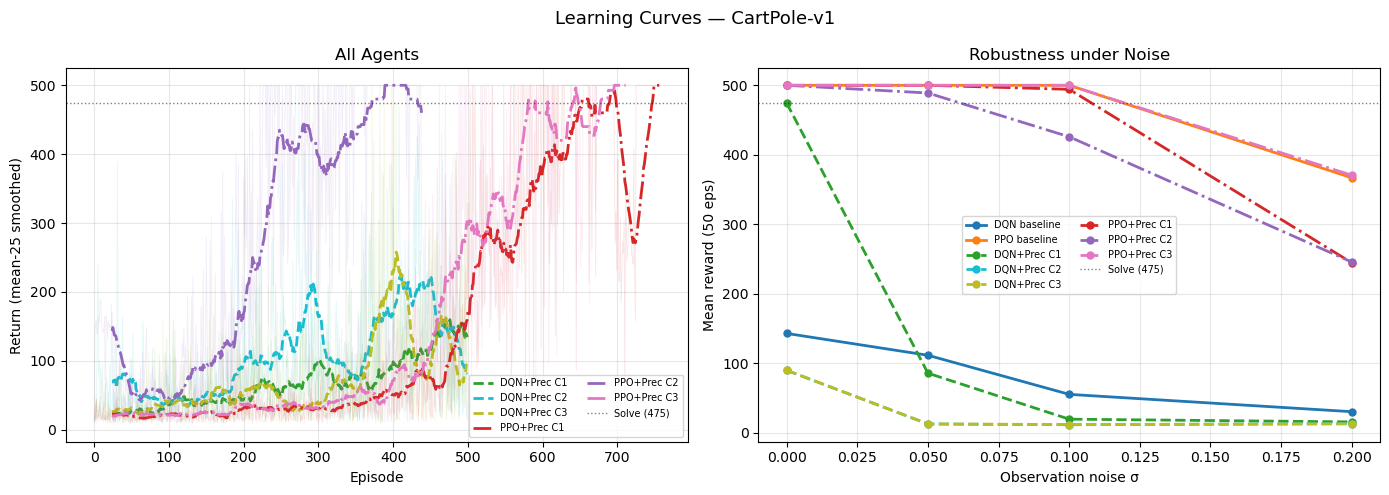

📊 Plot saved → eval_plots_CartPole/cartpole_eval_curves.png


In [70]:
COLORS = {
    "DQN baseline" : "#1f77b4",
    "PPO baseline" : "#ff7f0e",
    "DQN+Prec C1"  : "#2ca02c",
    "DQN+Prec C2"  : "#17becf",
    "DQN+Prec C3"  : "#bcbd22",
    "PPO+Prec C1"  : "#d62728",
    "PPO+Prec C2"  : "#9467bd",
    "PPO+Prec C3"  : "#e377c2",
}
STYLES = {
    "DQN baseline" : "-",
    "PPO baseline" : "-",
    "DQN+Prec C1"  : "--",
    "DQN+Prec C2"  : "--",
    "DQN+Prec C3"  : "--",
    "PPO+Prec C1"  : "-.",
    "PPO+Prec C2"  : "-.",
    "PPO+Prec C3"  : "-.",
}
WINDOW = 25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Learning Curves — {ENV_NAME}", fontsize=13)

# ── Left: all agents ──────────────────────────────────────────────
ax = axes[0]
for name, h in histories.items():
    if not h:
        continue
    rw  = np.array(h)
    col = COLORS.get(name, "grey")
    sty = STYLES.get(name, "-")
    ax.plot(rw, alpha=0.12, color=col, linewidth=0.6)
    if len(rw) >= WINDOW:
        ma = np.convolve(rw, np.ones(WINDOW)/WINDOW, mode='valid')
        ax.plot(np.arange(WINDOW-1, len(rw)), ma,
                color=col, linestyle=sty, linewidth=2.0, label=name)

ax.axhline(SOLVE_THRESH, color='k', linestyle=':', alpha=0.5, linewidth=1,
           label=f"Solve ({SOLVE_THRESH})")
ax.set_xlabel("Episode"); ax.set_ylabel("Return (mean-25 smoothed)")
ax.set_title("All Agents"); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

# ── Right: robustness curves ───────────────────────────────────────
ax = axes[1]
for name, noise_dict in robustness_results.items():
    sigmas = sorted(noise_dict.keys())
    means  = [noise_dict[s] for s in sigmas]
    col    = COLORS.get(name, "grey")
    sty    = STYLES.get(name, "-")
    ax.plot(sigmas, means, color=col, linestyle=sty,
            linewidth=2.0, marker='o', markersize=5, label=name)

ax.axhline(SOLVE_THRESH, color='k', linestyle=':', alpha=0.5, linewidth=1,
           label=f"Solve ({SOLVE_THRESH})")
ax.set_xlabel("Observation noise σ"); ax.set_ylabel("Mean reward (50 eps)")
ax.set_title("Robustness under Noise")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(PLOT_DIR, "cartpole_eval_curves.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Plot saved → {fig_path}")


## 10. Reward Distribution — Box Plot

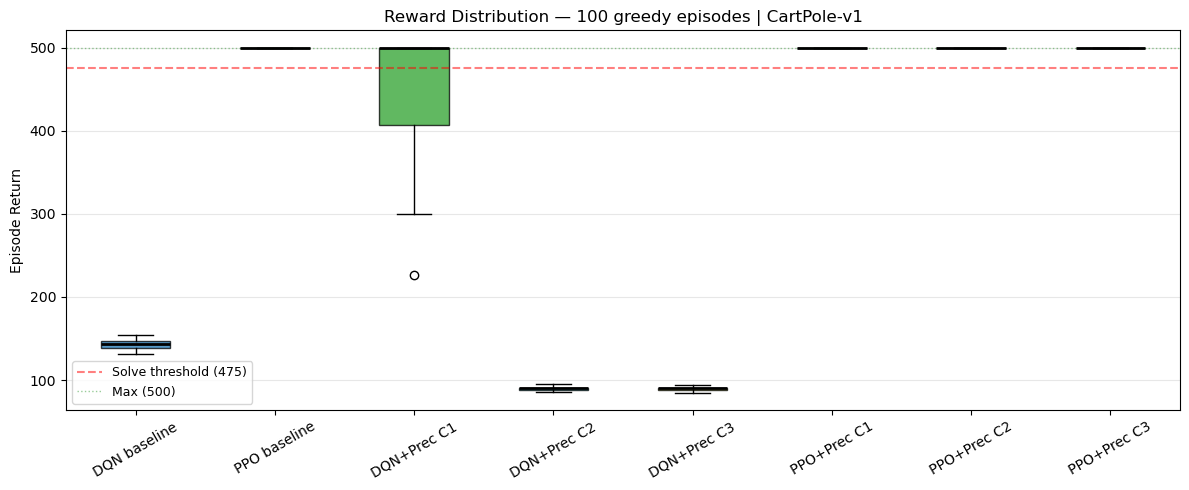

📊 Plot saved → eval_plots_CartPole/cartpole_eval_boxplot.png


In [71]:
fig, ax = plt.subplots(figsize=(12, 5))

names_list  = list(perf_results.keys())
rewards_list = [perf_results[n]['rewards'] for n in names_list]

bp = ax.boxplot(rewards_list, labels=names_list,
                patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))

for patch, name in zip(bp['boxes'], names_list):
    patch.set_facecolor(COLORS.get(name, '#aaaaaa'))
    patch.set_alpha(0.75)

ax.axhline(SOLVE_THRESH, color='red', linestyle='--', alpha=0.5,
           linewidth=1.5, label=f"Solve threshold ({SOLVE_THRESH})")
ax.axhline(500, color='green', linestyle=':', alpha=0.4,
           linewidth=1, label="Max (500)")
ax.set_ylabel("Episode Return")
ax.set_title(f"Reward Distribution — {N_EVAL_EPS} greedy episodes | {ENV_NAME}")
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(PLOT_DIR, "cartpole_eval_boxplot.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Plot saved → {fig_path}")


## 11. Robustness Heatmap

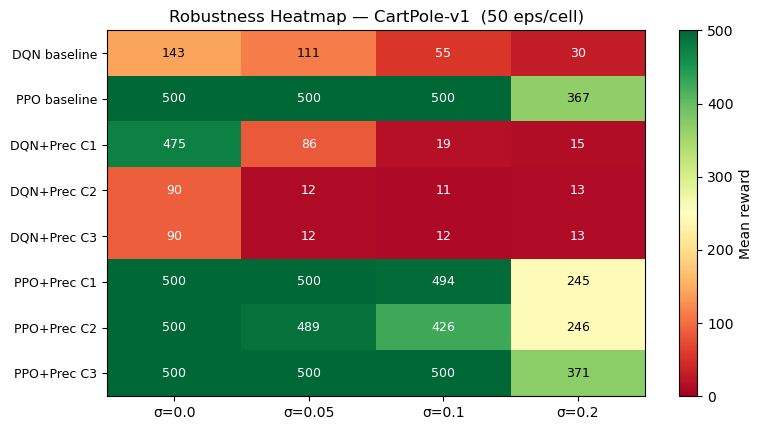

📊 Plot saved → eval_plots_CartPole/cartpole_robustness_heatmap.png


In [72]:
names_r  = list(robustness_results.keys())
sigmas   = sorted(NOISE_LEVELS)
matrix   = np.array([[robustness_results[n][s] for s in sigmas]
                      for n in names_r])

fig, ax  = plt.subplots(figsize=(8, max(4, len(names_r)*0.55)))
im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn',
               vmin=0, vmax=500)
plt.colorbar(im, ax=ax, label='Mean reward')

for i in range(len(names_r)):
    for j in range(len(sigmas)):
        ax.text(j, i, f"{matrix[i,j]:.0f}",
                ha='center', va='center', fontsize=9,
                color='black' if 100 < matrix[i,j] < 420 else 'white')

ax.set_xticks(range(len(sigmas)))
ax.set_xticklabels([f"σ={s}" for s in sigmas])
ax.set_yticks(range(len(names_r)))
ax.set_yticklabels(names_r, fontsize=9)
ax.set_title(f"Robustness Heatmap — {ENV_NAME}  ({N_ROBUST_EPS} eps/cell)")
plt.tight_layout()
fig_path = os.path.join(PLOT_DIR, "cartpole_robustness_heatmap.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Plot saved → {fig_path}")


## 12. Summary Table (paper-ready)

In [73]:
rows = []
for name in agents.keys():
    p  = perf_results.get(name, {})
    s  = stability_results.get(name, {})
    ep = solve_results.get(name, None)
    rb = robustness_results.get(name, {})

    rows.append({
        'Agent'               : name,
        'Mean reward (100 ep)': f"{p.get('mean', float('nan')):.1f}",
        'Std reward'          : f"{p.get('std',  float('nan')):.1f}",
        'Min / Max'           : f"{p.get('min', 0):.0f} / {p.get('max', 0):.0f}",
        'Train std (last 50)' : f"{s.get('std',  float('nan')):.1f}" if s else "—",
        'Episodes to solve'   : str(ep) if ep and ep > 0 else ("never" if ep == -1 else "—"),
        'Robust σ=0.1'        : f"{rb.get(0.1, float('nan')):.1f}",
        'Robust σ=0.2'        : f"{rb.get(0.2, float('nan')):.1f}",
    })

df = pd.DataFrame(rows).set_index('Agent')

# ── Print nicely ──────────────────────────────────────────────────
try:
    from IPython.display import display
    display(df)
except Exception:
    print(df.to_string())

# ── Save as CSV ───────────────────────────────────────────────────
csv_path = os.path.join(PLOT_DIR, "cartpole_eval_summary.csv")
df.to_csv(csv_path)
print(f"\n💾 Summary CSV saved → {csv_path}")


,Mean reward (100 ep),Std reward,Min / Max,Train std (last 50),Episodes to solve,Robust σ=0.1,Robust σ=0.2
Agent,,,,,,,
DQN baseline,143.2,5.0,132 / 154,—,—,55.1,30.1
PPO baseline,500.0,0.0,500 / 500,—,—,500.0,366.9
DQN+Prec C1,455.6,70.9,227 / 500,91.5,never,19.4,15.4
DQN+Prec C2,89.7,2.1,86 / 95,80.5,never,11.3,12.9
DQN+Prec C3,89.8,2.2,85 / 94,90.5,never,11.6,12.6
PPO+Prec C1,500.0,0.0,500 / 500,120.1,654,494.2,244.5
PPO+Prec C2,500.0,0.0,500 / 500,66.9,373,425.9,245.6
PPO+Prec C3,500.0,0.0,500 / 500,50.8,582,500.0,370.6



💾 Summary CSV saved → eval_plots_CartPole/cartpole_eval_summary.csv


## 13. Save All Evaluation Results (JSON)

In [74]:
eval_export = {
    'env'              : ENV_NAME,
    'n_eval_eps'       : N_EVAL_EPS,
    'solve_threshold'  : SOLVE_THRESH,
    'noise_levels'     : NOISE_LEVELS,
    'performance'      : {n: {k: v for k, v in r.items() if k != 'rewards'}
                          for n, r in perf_results.items()},
    'sample_efficiency': solve_results,
    'stability'        : stability_results,
    'robustness'       : robustness_results,
}

out_path = os.path.join(PLOT_DIR, "cartpole_eval_results.json")
with open(out_path, 'w') as f:
    json.dump(eval_export, f, indent=4)

print(f"✅ Evaluation results saved → {out_path}")
print(f"\n✅ Done! All outputs in: {PLOT_DIR}/")
print(f"  cartpole_eval_curves.png")
print(f"  cartpole_eval_boxplot.png")
print(f"  cartpole_robustness_heatmap.png")
print(f"  cartpole_eval_summary.csv")
print(f"  cartpole_eval_results.json")


✅ Evaluation results saved → eval_plots_CartPole/cartpole_eval_results.json

✅ Done! All outputs in: eval_plots_CartPole/
  cartpole_eval_curves.png
  cartpole_eval_boxplot.png
  cartpole_robustness_heatmap.png
  cartpole_eval_summary.csv
  cartpole_eval_results.json
